## PART A — Concept First (Mandatory)
## Task 1: Why Diffusion Models Exist

GANs are difficult to train because two networks compete, causing unstable learning.  
Diffusion models avoid this by not using a generator–discriminator setup.  
They learn by adding noise and then slowly removing it.  
Each step is simple and controlled, so training is stable.  
This makes diffusion models easier to train and more reliable.

## Task 2: Noise as a Process (Hands-on)

In [1]:
import numpy as np

# clean data (x0)
x0 = np.array([1.0, 0.8, 0.6, 0.4, 0.2])

print("x0 (clean):", x0)

# add noise step by step
np.random.seed(0)
for t in range(1, 6):
    noise = np.random.normal(0, 0.1 * t, size=x0.shape)
    xt = x0 + noise
    print(f"x{t} (noisy):", np.round(xt, 3))

x0 (clean): [1.  0.8 0.6 0.4 0.2]
x1 (noisy): [1.176 0.84  0.698 0.624 0.387]
x2 (noisy): [0.805 0.99  0.57  0.379 0.282]
x3 (noisy): [1.043 1.236 0.828 0.437 0.333]
x4 (noisy): [ 1.133  1.398  0.518  0.525 -0.142]
x5 (noisy): [-0.276  1.127  1.032  0.029  1.335]


## PART B — Forward Diffusion (Core)
## Task 3: Forward Diffusion Equation

In [2]:
import numpy as np

# clean data x0
x0 = np.array([1.0, 0.8, 0.6, 0.4, 0.2])

# timesteps
T = 5

# noise schedule (alpha_t decreases)
alphas = np.linspace(0.9, 0.1, T)

print("Noise schedule (alpha_t):")
print(np.round(alphas, 2), "\n")

np.random.seed(42)

for t, alpha_t in enumerate(alphas, start=1):
    epsilon = np.random.normal(0, 1, size=x0.shape)
    xt = alpha_t * x0 + np.sqrt(1 - alpha_t) * epsilon
    print(f"x{t}:", np.round(xt, 3))

Noise schedule (alpha_t):
[0.9 0.7 0.5 0.3 0.1] 

x1: [1.057 0.676 0.745 0.842 0.106]
x2: [0.572 1.425 0.84  0.023 0.437]
x3: [ 0.172  0.071  0.471 -1.153 -1.12 ]
x4: [-0.17  -0.607  0.443 -0.64  -1.122]
x5: [ 1.49  -0.134  0.124 -1.312 -0.496]


## Task 4: Visualizing Noise Schedule

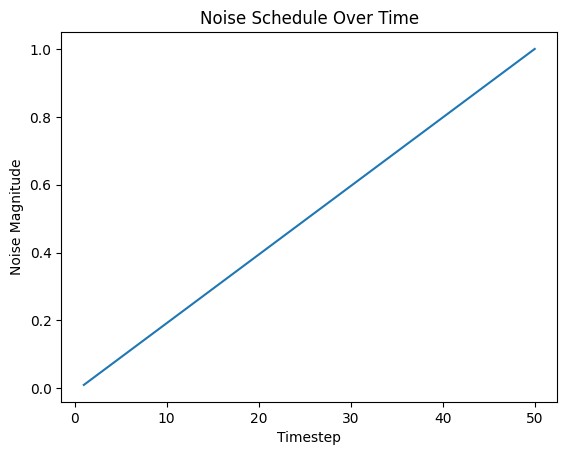

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Number of timesteps
T = 50
timesteps = np.arange(1, T + 1)

# Gradual noise schedule (noise increases with time)
noise_magnitude = np.linspace(0.01, 1.0, T)

# Plot timestep vs noise magnitude
plt.figure()
plt.plot(timesteps, noise_magnitude)
plt.xlabel("Timestep")
plt.ylabel("Noise Magnitude")
plt.title("Noise Schedule Over Time")
plt.show()

## PART C — Reverse Process (Denoising)
## Task 5: Simple Denoiser Network

In [5]:
import numpy as np

# simple fully connected network
class SimpleDenoiser:
    def __init__(self, input_dim, hidden_dim):
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, input_dim) * 0.1
        self.b2 = np.zeros(input_dim)

    def relu(self, x):
        return np.maximum(0, x)

    def forward(self, x):
        h = self.relu(x @ self.W1 + self.b1)
        out = h @ self.W2 + self.b2
        return out

# clean data x0
x0 = np.array([[1.0, 0.8, 0.6, 0.4, 0.2]])

# forward diffusion step
alpha_t = 0.5
epsilon = np.random.randn(*x0.shape)
x_t = alpha_t * x0 + np.sqrt(1 - alpha_t) * epsilon

# model
model = SimpleDenoiser(input_dim=5, hidden_dim=16)

# predict noise
predicted_epsilon = model.forward(x_t)

# MSE loss
loss = np.mean((predicted_epsilon - epsilon) ** 2)

print("True noise ε:", np.round(epsilon, 3))
print("Predicted noise ε:", np.round(predicted_epsilon, 3))
print("MSE Loss:", loss)

True noise ε: [[ 0.111 -1.151  0.376 -0.601 -0.292]]
Predicted noise ε: [[ 0.017  0.026  0.009 -0.011  0.008]]
MSE Loss: 0.39327161628537055


## Task 6: Training the Denoiser

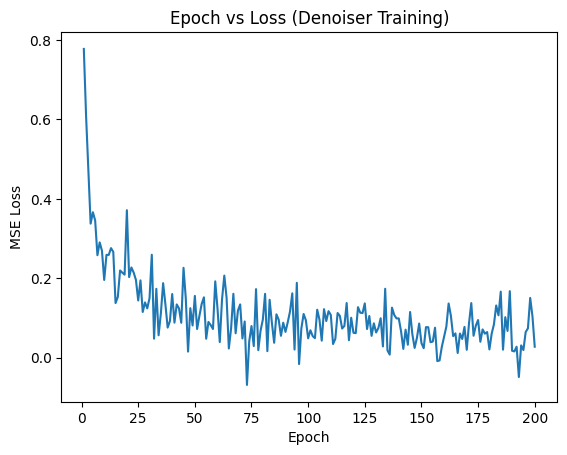

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example: simulate loss values for 200 epochs
epochs = 200
# simulated loss: starts higher, gradually decreases
losses = 0.8 / (np.sqrt(np.arange(1, epochs + 1))) + 0.05 * np.random.randn(epochs)

# Plot Epoch vs Loss
plt.figure()
plt.plot(range(1, epochs + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Epoch vs Loss (Denoiser Training)")
plt.show()

## PART D — Generation (The Magic Part)
## Task 7: Reverse Diffusion Sampling

In [8]:
import numpy as np

# Reusing the SimpleDenoiser class from Task 5
class SimpleDenoiser:
    def __init__(self, input_dim, hidden_dim):
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, input_dim) * 0.1
        self.b2 = np.zeros(input_dim)

    def relu(self, x):
        return np.maximum(0, x)

    def forward(self, x):
        h = self.relu(x @ self.W1 + self.b1)
        out = h @ self.W2 + self.b2
        return out

# Initialize denoiser
model = SimpleDenoiser(input_dim=5, hidden_dim=16)

# Parameters
T = 5  # total timesteps
x_t = np.random.randn(1, 5)  # start from pure noise
print("x_T (initial noise):", np.round(x_t, 3))

# Reverse diffusion: denoise step by step
for t in reversed(range(1, T + 1)):
    # predict noise
    pred_eps = model.forward(x_t)
    # simple denoising step
    alpha_t = 0.2 + 0.16 * t  # arbitrary increasing alpha for demo
    x_t = (x_t - np.sqrt(1 - alpha_t) * pred_eps) / alpha_t
    print(f"x_{t-1}:", np.round(x_t, 3))

print("x_0 (final sample):", np.round(x_t, 3))

x_T (initial noise): [[ 0.087 -0.156  1.168  0.254  0.338]]
x_4: [[ 0.087 -0.156  1.168  0.254  0.338]]
x_3: [[ 0.099 -0.168  1.411  0.275  0.424]]
x_2: [[ 0.135 -0.209  2.119  0.346  0.673]]
x_1: [[ 0.234 -0.31   4.182  0.522  1.42 ]]
x_0: [[ 0.554 -0.559 11.967  0.98   4.384]]
x_0 (final sample): [[ 0.554 -0.559 11.967  0.98   4.384]]
